# 06 - Product Analysis

## Objective

This notebook analyzes product and category performance using the Gold analytical tables.

The objectives are to:

- measure product and category sales performance;
- identify the main revenue-generating categories;
- analyze sales volume and average selling price;
- measure revenue concentration;
- evaluate freight cost by product category;
- analyze customer satisfaction by category;
- identify high-performing and underperforming products;
- generate actionable product-level business insights.

## Table of Contents

1. Product Overview
2. Category Performance
3. Revenue Analysis
4. Sales Volume
5. Price Analysis
6. Freight Analysis
7. Product Concentration
8. Customer Satisfaction by Product
9. Product Performance Matrix
10. Key Product Insights

In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

pd.set_option("Display.max_rows", 999)
pd.set_option("Display.max_columns", 999)

file_path = r"..\data\gold\olist_"
gold_orders = pd.read_parquet(file_path + "orders.parquet")
gold_products = pd.read_parquet(file_path + "products.parquet")
gold_customers = pd.read_parquet(file_path + "customers.parquet")

silver_products = pd.read_parquet(r"..\data\silver\olist_products_dataset.parquet")
silver_order_items = pd.read_parquet(r"..\data\silver\olist_order_items_dataset.parquet")


In [201]:
gold_products.columns

Index(['product_id', 'product_name_length', 'product_category_name',
       'product_description_length', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'nb_orders', 'units_sold', 'revenue', 'freight_revenue',
       'avg_selling_price', 'avg_freight', 'avg_review_score'],
      dtype='str')

In [202]:
product_kpis = {
    "unique_products": gold_products["product_id"].nunique(),
    "total_units_sold": gold_products["units_sold"].sum(),
    "product_revenue": gold_products["revenue"].sum(),
    "avg_product_price": gold_products["avg_selling_price"].mean(),
    "avg_review_score": gold_products["avg_review_score"].mean(),
    "weighted_avg_price" : (
    gold_products["revenue"].sum()
    / gold_products["units_sold"].sum()
)
}

pd.Series(product_kpis)


unique_products       3.295100e+04
total_units_sold      1.126500e+05
product_revenue       1.359164e+07
avg_product_price     1.453025e+02
avg_review_score      4.047807e+00
weighted_avg_price    1.206537e+02
dtype: float64

## 2. Category Performance

In [203]:
df = silver_products.merge(
    silver_order_items ,#.loc[: , ["product_id" , "price" ,"freight_value" ]] ,
     on ='product_id' ,
      how="left")

In [204]:
df.columns

Index(['product_id', 'product_name_length', 'product_category_name',
       'product_description_length', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'order_id', 'order_item_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value'],
      dtype='str')

In [205]:
category_perf = (
    df.groupby("product_category_name")
    .agg(
        products=("product_id", "nunique"),
        orders=("order_id", "nunique"),
        units_sold=("order_item_id", "count"),
        revenue=("price", "sum"),
        freight_revenue=("freight_value", "sum"),
        avg_price=("price", "mean"),
    )
    .reset_index()
)


In [206]:
category_perf["revenue_share"] = (
    category_perf["revenue"] / category_perf["revenue"].sum()
) * 100

# category_perf = category_perf.sort_values(by=["revenue_share"], ascending=False)

## 3. Revenue Analysis

In [207]:
top_categories_revenue = (
    category_perf
    .sort_values("revenue", ascending=False)
    .head(15)
)

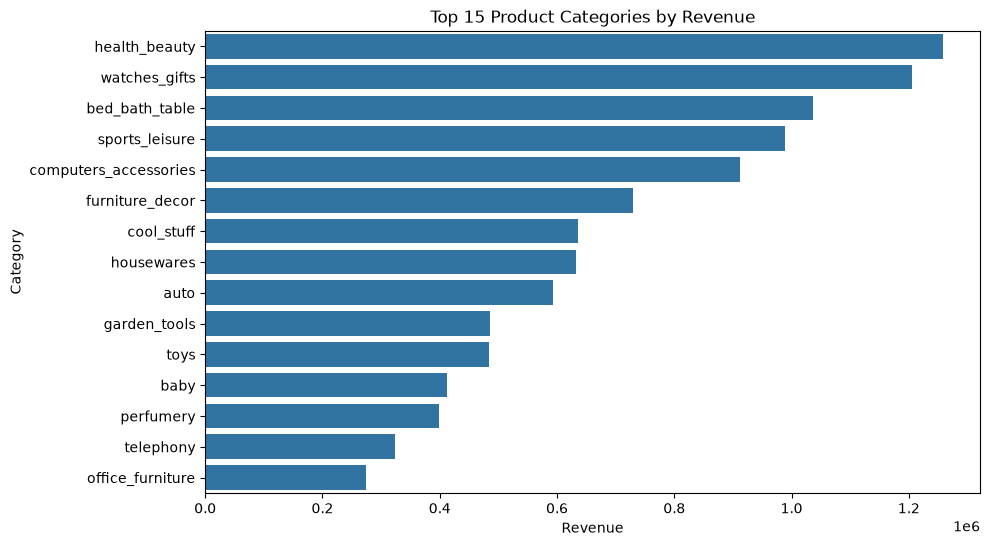

In [208]:
plt.figure(figsize=(10, 6))

sns.barplot(data=top_categories_revenue, x="revenue", y="product_category_name")

plt.title("Top 15 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.show()


## 4. Sales Volume

In [209]:
top_categories_volume = (
    category_perf
    .sort_values("units_sold", ascending=False)
    .head(15)
)

In [210]:
figsize = (10, 6)


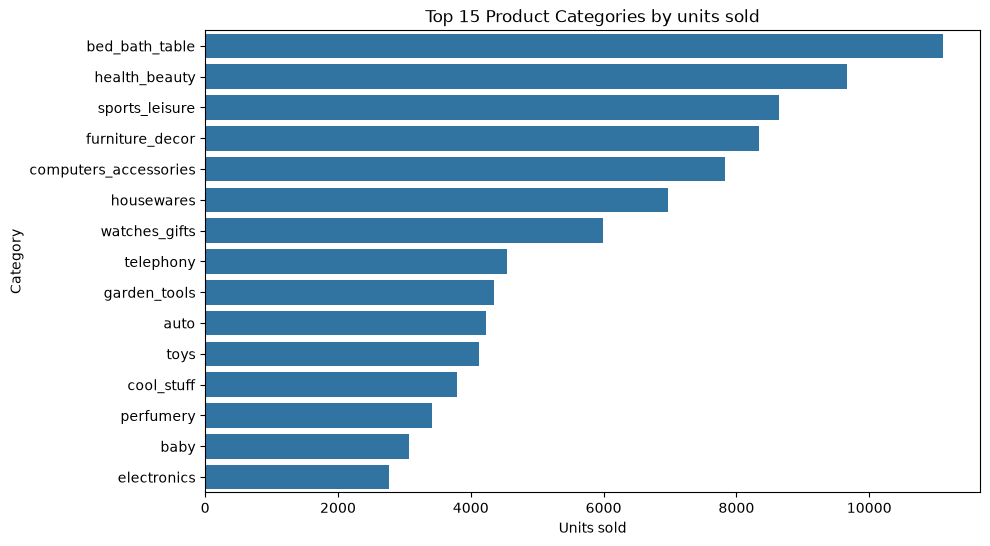

In [211]:
plt.figure(figsize=figsize)

sns.barplot(data=top_categories_volume, x="units_sold", y="product_category_name")

plt.title("Top 15 Product Categories by units sold")
plt.xlabel("Units sold")
plt.ylabel("Category")

plt.show()


### Revenue vs Sales Volume

The ranking of product categories differs significantly depending on whether performance
is measured by revenue or units sold.

`bed_bath_table` is the leading category in terms of sales volume, but ranks behind
`health_beauty` and `watches_gifts` in terms of revenue.

In contrast, `watches_gifts` generates one of the highest levels of revenue despite a
substantially lower sales volume.

This indicates that category performance is driven not only by demand volume but also
by differences in average selling price.

## 5. Price Analysis

In [212]:
category_price = (
    df.groupby("product_category_name")
    .agg(
        nb_orders=("order_id", "nunique"),
        units_sold=("order_item_id", "count"),
        revenue=("price", "sum"),
        avg_price=("price", "mean"),
        median_price=("price", "median"),
        min_price=("price", "min"),
        max_price=("price", "max"),
    )
    .reset_index()
)

category_price = category_price[category_price["nb_orders"] >= 100]
category_price["mean_median_gap"] = (
    category_price["avg_price"] - category_price["median_price"]
)
category_price["mean_median_ratio"] = (
    category_price["avg_price"] / category_price["median_price"]
)

top_avg_price = category_price.sort_values("avg_price", ascending=False).head(15)

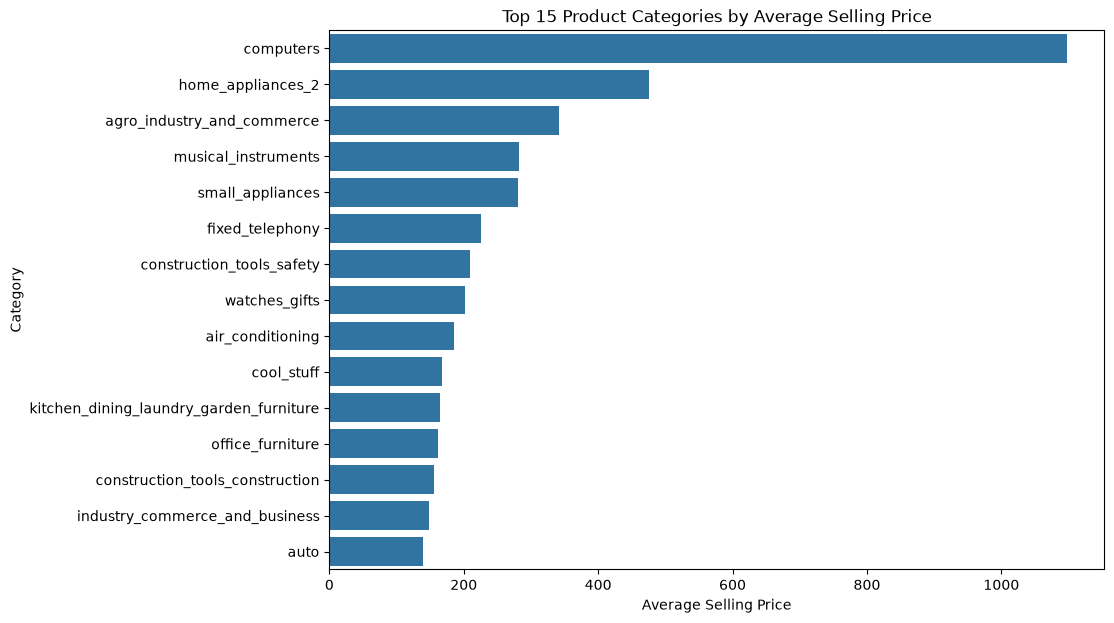

In [213]:
plt.figure(figsize=(10, 7))

sns.barplot(data=top_avg_price, x="avg_price", y="product_category_name")

plt.title("Top 15 Product Categories by Average Selling Price")
plt.xlabel("Average Selling Price")
plt.ylabel("Category")

plt.show()


### Price Distribution Across Categories

Product categories show substantial differences in selling price.

`computers` stands out as the most expensive category, with an average selling price
close to 1,100 and a median price at a similar level. This indicates that the category
is structurally high-priced rather than being driven by a small number of extreme values.

Several other categories exhibit strong right-skewness. For example, `fixed_telephony`,
`musical_instruments` and `small_appliances` have average prices that are several times
higher than their median prices.

This suggests that most transactions in these categories occur at relatively moderate
prices, while a smaller number of high-value sales substantially increase the average.

In [220]:
category_price[
    [
        "product_category_name",
        "nb_orders",
        "units_sold",
        "avg_price",
        "median_price",
        "mean_median_ratio",
    ]
].sort_values("avg_price", ascending=False).head(15)


,product_category_name,nb_orders,units_sold,avg_price,median_price,mean_median_ratio
14,computers,181,203,1098.340542,1100.000,0.998491
45,home_appliances_2,234,238,476.124958,225.945,2.107260
0,agro_industry_and_commerce,182,212,342.124858,258.650,1.322733
56,musical_instruments,628,680,281.616000,94.835,2.969537
65,small_appliances,630,679,280.778468,99.000,2.836146
34,fixed_telephony,217,264,225.693182,64.485,3.499933
19,construction_tools_safety,167,194,208.992371,125.575,1.664283
73,watches_gifts,5624,5991,201.135984,129.000,1.559194
1,air_conditioning,253,297,185.269226,139.990,1.323446
20,cool_stuff,3632,3796,167.357969,129.990,1.287468


### Premium vs Volume-Oriented Categories

Price differences help explain why revenue rankings differ from sales-volume rankings.

`watches_gifts`, for example, has an average selling price of approximately 201 and a
median price of 129. Despite selling fewer units than categories such as
`bed_bath_table`, it generates one of the highest levels of revenue.

This indicates a more premium revenue profile, where higher unit prices compensate for
lower sales volume.

In contrast, some categories depend more heavily on large sales volumes rather than
high unit prices.

## 6. freight Analysis

In [214]:
category_freight = (
    df.groupby("product_category_name")
    .agg(
        revenue=("price", "sum"),
        freight=("freight_value", "sum"),
        avg_freight=("freight_value", "mean"),
        nb_orders=("order_id", "nunique"),
    )
    .reset_index()
)

category_freight["freight_to_product_ratio"] = (
    category_freight["freight"] / category_freight["revenue"]
)
category_freight_filtered = category_freight[category_freight["nb_orders"] >= 100]
category_freight_filtered = category_freight_filtered.sort_values(
    by="freight_to_product_ratio", ascending=False
)


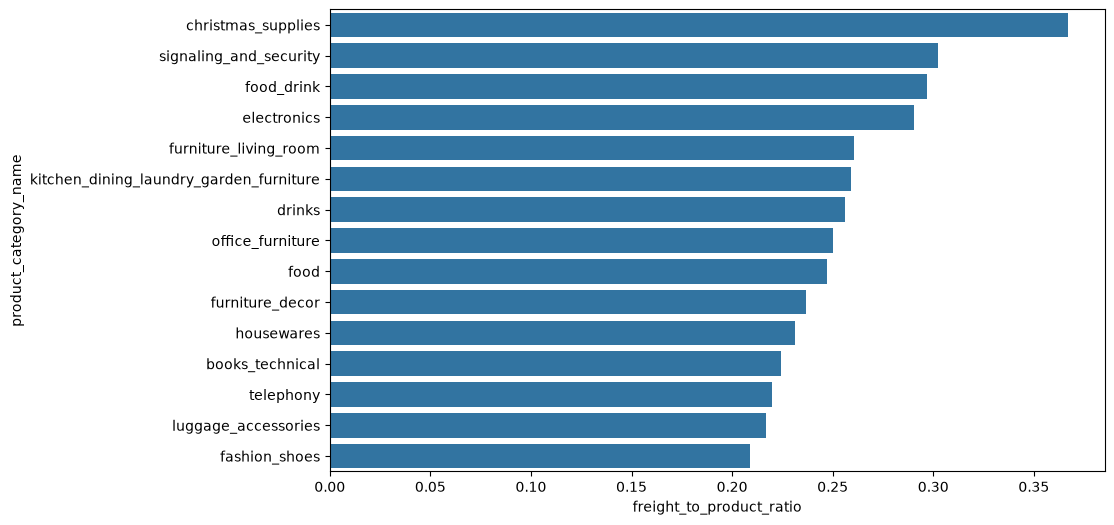

In [215]:
plt.figure(figsize = figsize)
sns.barplot(
    y="product_category_name",
    x="freight_to_product_ratio",
    data=category_freight_filtered.iloc[:15,],
)
plt.show()

### Freight Burden by Product Category

After excluding categories with fewer than 100 orders, substantial differences in freight burden remain.

`christmas_supplies` shows the highest freight-to-product ratio, followed by categories such as
`signaling_and_security`, `food_drink` and `electronics`.

For the most affected categories, freight represents roughly 25% to 37% of product revenue.

This suggests that logistics costs are structurally more important for some product categories,
potentially due to product size, weight, shipping distance or lower average selling prices.

## 7. Product Concentration

In [216]:
pareto = (
    gold_products
    .sort_values("revenue", ascending=False)
    .copy()
)

pareto["cumulative_revenue"] = pareto["revenue"].cumsum()

pareto["cumulative_revenue_share"] = (
    pareto["cumulative_revenue"]
    / pareto["revenue"].sum()
)

pareto["product_share"] = (
    np.arange(1, len(pareto) + 1)
    / len(pareto)
)

pareto[pareto["cumulative_revenue_share"] >= 0.80].head(1)

,product_id,product_name_length,product_category_name,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,nb_orders,units_sold,revenue,freight_revenue,avg_selling_price,avg_freight,avg_review_score,cumulative_revenue,cumulative_revenue_share,product_share
26335,d41fdddc347b82c2904b477df7fcea9e,52.0,furniture_decor,299.0,1.0,14000.0,45.0,45.0,50.0,2,2,313.98,126.36,156.99,63.18,4.0,10873463.56,0.800011,0.259051


### Revenue Concentration

Product revenue is relatively concentrated.

Approximately **25.9% of products generate 80% of total product revenue**.

Although the distribution does not strictly follow the classical 80/20 Pareto rule,
the result indicates that a relatively limited portion of the product catalog accounts
for the majority of sales value.

This suggests that product assortment management could focus particular attention on
this core group of revenue-generating products.

## 8. Customer Satisfaction by Product

In [217]:
silver_order_reviews = pd.read_parquet(r"..\data\silver\olist_order_reviews_dataset.parquet")

In [218]:
df = silver_products.merge(
    silver_order_items ,
    on ="product_id",
    how="left"
).merge(silver_order_reviews ,
on ="order_id" , 
how="left")

category_reviews = (
    df.groupby("product_category_name")
    .agg(avg_review_score=("review_score", "mean"), reviews=("review_score", "count"))
    .reset_index()
)

category_reviews = category_reviews[category_reviews["reviews"] >= 100]

category_reviews.sort_values(by =["avg_review_score" , "reviews"] , ascending = False).head(15)

,product_category_name,avg_review_score,reviews
8,books_general_interest,4.446266,549
10,books_technical,4.368421,266
37,food_drink,4.315412,279
53,luggage_accessories,4.315257,1088
31,fashion_shoes,4.233716,261
36,food,4.218182,495
68,stationery,4.193857,2507
61,pet_shop,4.185147,1939
14,computers,4.175000,200
44,home_appliances,4.172457,806


## 9. Product Performance Matrix

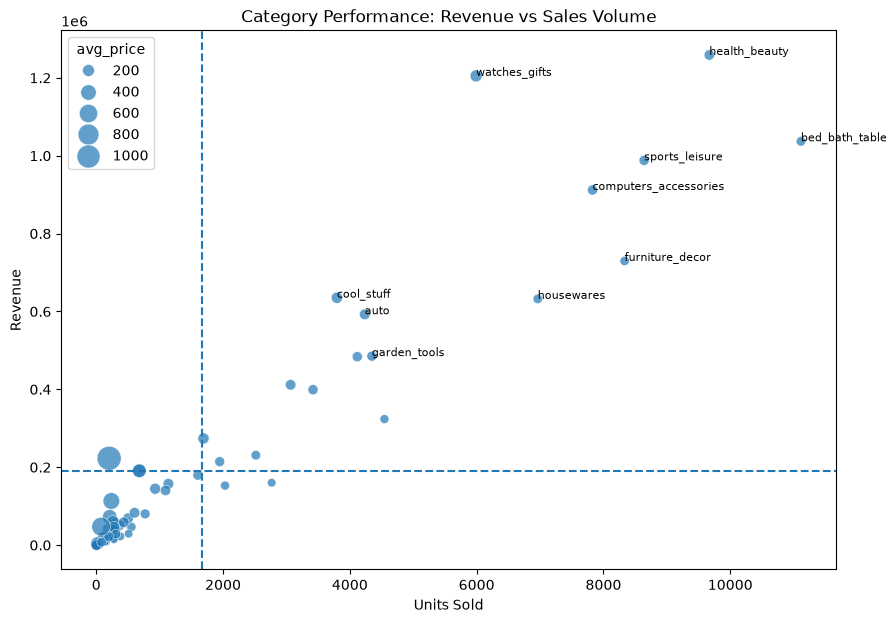

In [219]:
plt.figure(figsize=(10, 7))
median_units = category_perf["units_sold"].median()
median_revenue = category_perf["revenue"].median()
x_threshold = category_perf["units_sold"].quantile(0.75)
y_threshold = category_perf["revenue"].quantile(0.75)
sns.scatterplot(
    data=category_perf,
    x="units_sold",
    y="revenue",
    size="avg_price",
    sizes=(30, 300),
    alpha=0.7,
)

top_categories = category_perf.nlargest(10, "revenue")

for _, row in top_categories.iterrows():
    plt.text(
        row["units_sold"], row["revenue"], row["product_category_name"], fontsize=8
    )

plt.axvline(x_threshold, linestyle="--")
plt.axhline(y_threshold, linestyle="--")
plt.title("Category Performance: Revenue vs Sales Volume")
plt.xlabel("Units Sold")
plt.ylabel("Revenue")

plt.show()


### Product Performance Matrix

Product categories were segmented using sales volume and revenue.

The 75th percentile was used as a threshold to distinguish high-performing
categories from the rest of the catalog.

The resulting segments are:

- **Core / Star**: high sales volume and high revenue;
- **Premium / High Value**: lower sales volume but high revenue;
- **High Volume / Lower Value**: strong demand but comparatively lower revenue;
- **Long Tail**: lower sales volume and lower revenue.

This segmentation provides a more strategic view of category performance than
revenue or sales volume alone.

In [221]:
x_threshold = category_perf["units_sold"].quantile(0.75)
y_threshold = category_perf["revenue"].quantile(0.75)


def classify_category(row):
    if row["units_sold"] >= x_threshold and row["revenue"] >= y_threshold:
        return "Core / Star"
    elif row["units_sold"] < x_threshold and row["revenue"] >= y_threshold:
        return "Premium / High Value"
    elif row["units_sold"] >= x_threshold and row["revenue"] < y_threshold:
        return "High Volume / Lower Value"
    else:
        return "Long Tail"


category_perf["performance_segment"] = category_perf.apply(classify_category, axis=1)


In [223]:
category_perf[
    [
        "product_category_name",
        "units_sold",
        "revenue",
        "avg_price",
        "performance_segment",
    ]
].sort_values(["performance_segment", "revenue"], ascending=[True, False]).head(15)


,product_category_name,units_sold,revenue,avg_price,performance_segment
43,health_beauty,9670,1258681.34,130.163531,Core / Star
73,watches_gifts,5991,1205005.68,201.135984,Core / Star
7,bed_bath_table,11115,1036988.68,93.296327,Core / Star
67,sports_leisure,8641,988048.97,114.344285,Core / Star
15,computers_accessories,7827,911954.32,116.513903,Core / Star
39,furniture_decor,8334,729762.49,87.564494,Core / Star
20,cool_stuff,3796,635290.85,167.357969,Core / Star
49,housewares,6964,632248.66,90.788148,Core / Star
5,auto,4235,592720.11,139.957523,Core / Star
42,garden_tools,4347,485256.46,111.630196,Core / Star


## 10. Key Product Insights

### 1. Revenue is concentrated among a limited share of products

Approximately 25.9% of products generate 80% of total product revenue.

This indicates that a relatively small portion of the catalog drives most of
the business value.

### 2. Sales volume and revenue rankings differ substantially

The best-selling categories are not always the highest-revenue categories.

`bed_bath_table` leads in sales volume, while categories such as
`health_beauty` and `watches_gifts` generate higher revenue.

### 3. Average selling price strongly influences category performance

`watches_gifts` generates high revenue despite lower sales volume because its
average selling price is significantly higher than that of many high-volume
categories.

### 4. Some categories exhibit highly skewed price distributions

Categories such as `fixed_telephony`, `musical_instruments` and
`small_appliances` show average prices several times higher than their median
prices.

This indicates that a small number of high-value transactions substantially
influence the average selling price.

### 5. Freight burden varies significantly across categories

After restricting the analysis to categories with at least 100 orders, some
categories still show freight-to-product ratios above 25%.

This suggests that logistics represent a more important component of customer
cost for certain product families.

### 6. Customer satisfaction remains generally high across major categories

Several categories combine large review volumes with average review scores
above 4/5, indicating generally positive customer satisfaction.

However, category-level review performance should always be interpreted
together with the number of available reviews.

### 7. The product catalog contains a significant long tail

A large number of categories generate relatively low sales volume and revenue
compared with the leading categories.

This indicates that the marketplace relies on a combination of a few core
categories and a broad long-tail assortment.

## Business Implications

The analysis suggests several areas for business attention:

- protect the availability and visibility of core revenue-generating categories;
- monitor premium categories where high unit prices drive revenue;
- investigate categories with high freight-to-product ratios;
- review long-tail categories with limited commercial contribution;
- combine sales, pricing, logistics and customer satisfaction metrics when
  evaluating product performance.

In [228]:
gold_category_performance = (
    category_perf[
        [
            "product_category_name",
            "products",
            "orders",
            "units_sold",
            "revenue",
            "revenue_share",
            "avg_price",
        ]
    ]
    .merge(
        category_price[["product_category_name", "median_price", "mean_median_ratio"]],
        on="product_category_name",
        how="left",
    )
    .merge(
        category_freight[["product_category_name", "freight", "avg_freight"]],
        on="product_category_name",
        how="left",
    )
    .merge(
        category_reviews[["product_category_name", "avg_review_score", "reviews"]],
        on="product_category_name",
        how="left",
    )
)


gold_category_performance = gold_category_performance.rename(
    columns={
        "products": "nb_products",
        "orders": "nb_orders",
        "mean_median_ratio": "price_skew_indicator",
    }
)


gold_category_performance["freight_to_product_ratio"] = (
    gold_category_performance["freight"] / gold_category_performance["revenue"]
)



x_threshold = gold_category_performance["units_sold"].quantile(0.75)
y_threshold = gold_category_performance["revenue"].quantile(0.75)


def classify_category(row):
    if row["units_sold"] >= x_threshold and row["revenue"] >= y_threshold:
        return "Core / Star"

    elif row["units_sold"] < x_threshold and row["revenue"] >= y_threshold:
        return "Premium / High Value"

    elif row["units_sold"] >= x_threshold and row["revenue"] < y_threshold:
        return "High Volume / Lower Value"

    else:
        return "Long Tail"


gold_category_performance["performance_segment"] = gold_category_performance.apply(
    classify_category, axis=1
)





gold_category_performance = gold_category_performance[
    [
        "product_category_name",
        "nb_products",
        "nb_orders",
        "units_sold",
        "revenue",
        "revenue_share",
        "avg_price",
        "median_price",
        "price_skew_indicator",
        "freight",
        "avg_freight",
        "freight_to_product_ratio",
        "avg_review_score",
        "reviews",
        "performance_segment",
    ]
]

In [229]:
gold_category_performance.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   product_category_name     74 non-null     str    
 1   nb_products               74 non-null     int64  
 2   nb_orders                 74 non-null     int64  
 3   units_sold                74 non-null     int64  
 4   revenue                   74 non-null     float64
 5   revenue_share             74 non-null     float64
 6   avg_price                 74 non-null     float64
 7   median_price              52 non-null     float64
 8   price_skew_indicator      52 non-null     float64
 9   freight                   74 non-null     float64
 10  avg_freight               74 non-null     float64
 11  freight_to_product_ratio  74 non-null     float64
 12  avg_review_score          53 non-null     float64
 13  reviews                   53 non-null     float64
 14  performance_segment    

In [231]:
# ============================================================
# GOLD CATEGORY PERFORMANCE
# Grain: one row per product category
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. CATEGORY PERFORMANCE
# ------------------------------------------------------------

category_perf = (
    df.groupby("product_category_name")
    .agg(
        nb_products=("product_id", "nunique"),
        nb_orders=("order_id", "nunique"),
        units_sold=("order_item_id", "count"),
        revenue=("price", "sum"),
    )
    .reset_index()
)

category_perf["revenue_share"] = (
    category_perf["revenue"] / category_perf["revenue"].sum()
)

category_perf["avg_price"] = category_perf["revenue"] / category_perf["units_sold"]


# ------------------------------------------------------------
# 2. PRICE ANALYSIS
# ------------------------------------------------------------

category_price = (
    df.groupby("product_category_name")
    .agg(median_price=("price", "median"))
    .reset_index()
)

category_price["price_skew_indicator"] = np.nan


# On calcule le ratio après le merge, car avg_price est déjà
# disponible dans category_perf


# ------------------------------------------------------------
# 3. FREIGHT ANALYSIS
# ------------------------------------------------------------

category_freight = (
    df.groupby("product_category_name")
    .agg(freight=("freight_value", "sum"), avg_freight=("freight_value", "mean"))
    .reset_index()
)


# ------------------------------------------------------------
# 4. REVIEW / SATISFACTION ANALYSIS
# ------------------------------------------------------------

category_reviews = (
    df.groupby("product_category_name")
    .agg(avg_review_score=("review_score", "mean"), reviews=("review_score", "count"))
    .reset_index()
)


# ------------------------------------------------------------
# 5. BUILD FINAL GOLD TABLE
# ------------------------------------------------------------

gold_category_performance = (
    category_perf.merge(
        category_price[["product_category_name", "median_price"]],
        on="product_category_name",
        how="left",
    )
    .merge(
        category_freight[["product_category_name", "freight", "avg_freight"]],
        on="product_category_name",
        how="left",
    )
    .merge(
        category_reviews[["product_category_name", "avg_review_score", "reviews"]],
        on="product_category_name",
        how="left",
    )
)


# ------------------------------------------------------------
# 6. DERIVED METRICS
# ------------------------------------------------------------

gold_category_performance["price_skew_indicator"] = (
    gold_category_performance["avg_price"] / gold_category_performance["median_price"]
)

gold_category_performance["freight_to_product_ratio"] = (
    gold_category_performance["freight"] / gold_category_performance["revenue"]
)


# ------------------------------------------------------------
# 7. PERFORMANCE SEGMENTATION
# ------------------------------------------------------------

units_threshold = gold_category_performance["units_sold"].quantile(0.75)

revenue_threshold = gold_category_performance["revenue"].quantile(0.75)


def classify_category(row):
    if row["units_sold"] >= units_threshold and row["revenue"] >= revenue_threshold:
        return "Core / Star"

    elif row["units_sold"] < units_threshold and row["revenue"] >= revenue_threshold:
        return "Premium / High Value"

    elif row["units_sold"] >= units_threshold and row["revenue"] < revenue_threshold:
        return "High Volume / Lower Value"

    else:
        return "Long Tail"


gold_category_performance["performance_segment"] = gold_category_performance.apply(
    classify_category, axis=1
)


# ------------------------------------------------------------
# 8. COLUMN ORDER
# ------------------------------------------------------------

gold_category_performance = gold_category_performance[
    [
        "product_category_name",
        "nb_products",
        "nb_orders",
        "units_sold",
        "revenue",
        "revenue_share",
        "avg_price",
        "median_price",
        "price_skew_indicator",
        "freight",
        "avg_freight",
        "freight_to_product_ratio",
        "avg_review_score",
        "reviews",
        "performance_segment",
    ]
]


# ------------------------------------------------------------
# 9. SORT TABLE
# ------------------------------------------------------------

gold_category_performance = gold_category_performance.sort_values(
    "revenue", ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# 10. VALIDATION
# ------------------------------------------------------------

print("Shape:")
print(gold_category_performance.shape)

print("\nMissing values:")
print(gold_category_performance.isna().sum())

print("\nDuplicate categories:")
print(gold_category_performance["product_category_name"].duplicated().sum())

print("\nRevenue share:")
print(gold_category_performance["revenue_share"].sum())


assert gold_category_performance["product_category_name"].is_unique

assert (gold_category_performance["revenue"] >= 0).all()

assert (gold_category_performance["freight"] >= 0).all()

assert np.isclose(gold_category_performance["revenue_share"].sum(), 1.0)


# ------------------------------------------------------------
# 11. DISPLAY
# ------------------------------------------------------------

display(gold_category_performance.head(10))


# ------------------------------------------------------------
# 12. EXPORT
# ------------------------------------------------------------

gold_category_performance.to_parquet(
    "../data/gold/gold_category_performance.parquet", index=False
)

print("\n✅ gold_category_performance exported successfully.")


Shape:
(74, 15)

Missing values:
product_category_name       0
nb_products                 0
nb_orders                   0
units_sold                  0
revenue                     0
revenue_share               0
avg_price                   0
median_price                0
price_skew_indicator        0
freight                     0
avg_freight                 0
freight_to_product_ratio    0
avg_review_score            0
reviews                     0
performance_segment         0
dtype: int64

Duplicate categories:
0

Revenue share:
1.0000000000000002


,product_category_name,nb_products,nb_orders,units_sold,revenue,revenue_share,avg_price,median_price,price_skew_indicator,freight,avg_freight,freight_to_product_ratio,avg_review_score,reviews,performance_segment
0,health_beauty,2444,8836,9727,1263138.54,0.092525,129.859005,79.90,1.625269,183483.54,18.863323,0.145260,4.142768,9645,Core / Star
1,watches_gifts,1329,5624,6001,1206075.33,0.088345,200.979058,129.00,1.557977,100686.07,16.778215,0.083482,4.019160,5950,Core / Star
2,bed_bath_table,3029,9417,11270,1050936.61,0.076981,93.250808,79.05,1.179643,207252.90,18.389787,0.197208,3.895663,11137,Core / Star
3,sports_leisure,2867,7720,8700,993656.51,0.072785,114.213392,77.95,1.465213,169673.47,19.502698,0.170757,4.107986,8640,Core / Star
4,computers_accessories,1639,6689,7894,919640.54,0.067363,116.498675,81.99,1.420889,148429.94,18.802881,0.161400,3.930819,7849,Core / Star
5,furniture_decor,2657,6449,8415,736282.47,0.053933,87.496431,65.49,1.336027,174400.58,20.724965,0.236866,3.903493,8331,Core / Star
6,cool_stuff,789,3632,3806,637258.51,0.046679,167.435236,129.99,1.288062,84234.39,22.131999,0.132182,4.146341,3772,Core / Star
7,housewares,2335,5884,6989,634542.60,0.046480,90.791615,59.70,1.520798,146627.43,20.979744,0.231076,4.055019,6943,Core / Star
8,auto,1900,3897,4256,594363.10,0.043537,139.652984,84.90,1.644911,93011.09,21.854109,0.156489,4.065512,4213,Core / Star
9,garden_tools,753,3518,4361,486432.45,0.035631,111.541493,59.90,1.862128,99214.09,22.750307,0.203963,4.042735,4329,Core / Star



✅ gold_category_performance exported successfully.


In [232]:
gold_category_performance["performance_segment"].value_counts()


performance_segment
Long Tail                    53
Core / Star                  17
Premium / High Value          2
High Volume / Lower Value     2
Name: count, dtype: int64

In [233]:
segment_summary = (
    gold_category_performance.groupby("performance_segment")
    .agg(
        categories=("product_category_name", "count"),
        total_revenue=("revenue", "sum"),
        total_units=("units_sold", "sum"),
        avg_price=("avg_price", "mean"),
        avg_review_score=("avg_review_score", "mean"),
    )
    .reset_index()
)

segment_summary["category_share"] = (
    segment_summary["categories"] / segment_summary["categories"].sum()
)

segment_summary["revenue_share"] = (
    segment_summary["total_revenue"] / segment_summary["total_revenue"].sum()
)

segment_summary["unit_share"] = (
    segment_summary["total_units"] / segment_summary["total_units"].sum()
)

segment_summary.sort_values("total_revenue", ascending=False)


,performance_segment,categories,total_revenue,total_units,avg_price,avg_review_score,category_share,revenue_share,unit_share
0,Core / Star,17,10864382.48,92777,120.855330,4.027114,0.229730,0.795813,0.818760
2,Long Tail,53,2058972.84,14833,136.782644,4.006809,0.716216,0.150819,0.130902
3,Premium / High Value,2,414534.61,886,689.412936,4.162094,0.027027,0.030365,0.007819
1,High Volume / Lower Value,2,314033.54,4818,66.447061,4.091073,0.027027,0.023003,0.042519


### Product Category Segmentation

The category segmentation reveals a strong concentration of business activity.

`Core / Star` categories represent only **23.0% of the product categories**, yet they
generate approximately **79.6% of total revenue** and account for **81.9% of units sold**.

In contrast, the `Long Tail` represents more than **71% of the catalog**, but contributes
only **15.1% of revenue** and **13.1% of sales volume**.

The two `Premium / High Value` categories represent less than 1% of total units sold but
generate approximately 3% of revenue. Their average selling price is substantially higher
than that of the other segments, confirming their premium positioning.

The `High Volume / Lower Value` segment shows the opposite pattern: relatively strong
sales volume but a lower contribution to revenue due to lower average selling prices.